In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/insurance.csv')
print(df.shape)
df.head()



(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Data Inspection and Cleaning

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


np.int64(1)

In [5]:
# value distribution

print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())
print(df['children'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


Exploratory data analysis

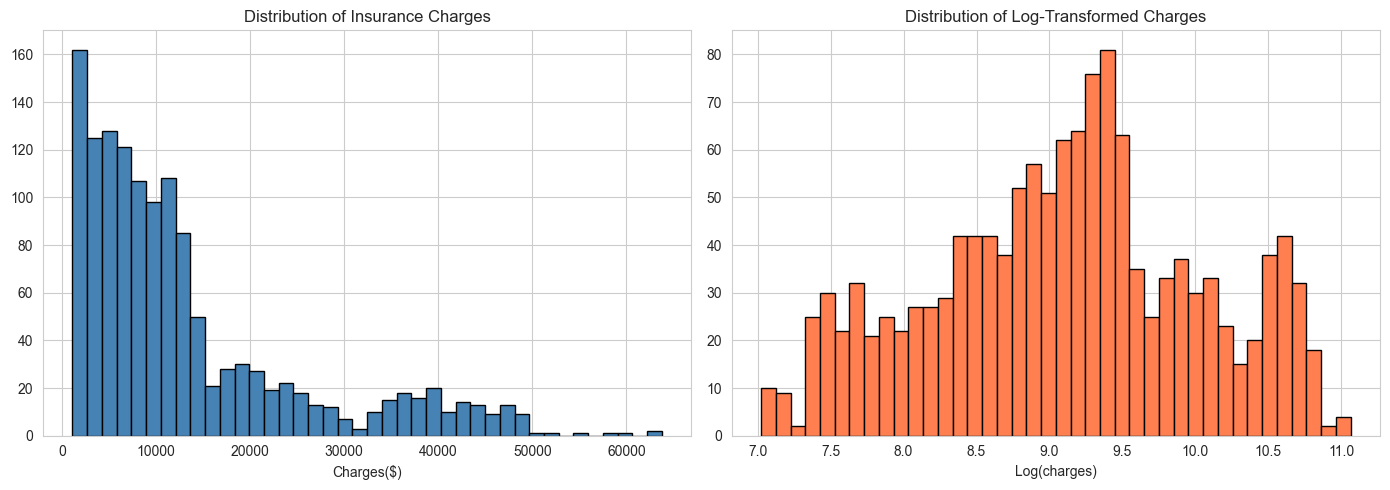

In [6]:
#distribution of charges
fig, axes =plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df['charges'],bins=40, color='steelblue',edgecolor='black')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges($)')

axes[1].hist(np.log1p(df['charges']),bins=40,color='coral',edgecolor='black')
axes[1].set_title('Distribution of Log-Transformed Charges')
axes[1].set_xlabel('Log(charges)')

plt.tight_layout()
plt.savefig('../figures/charges_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

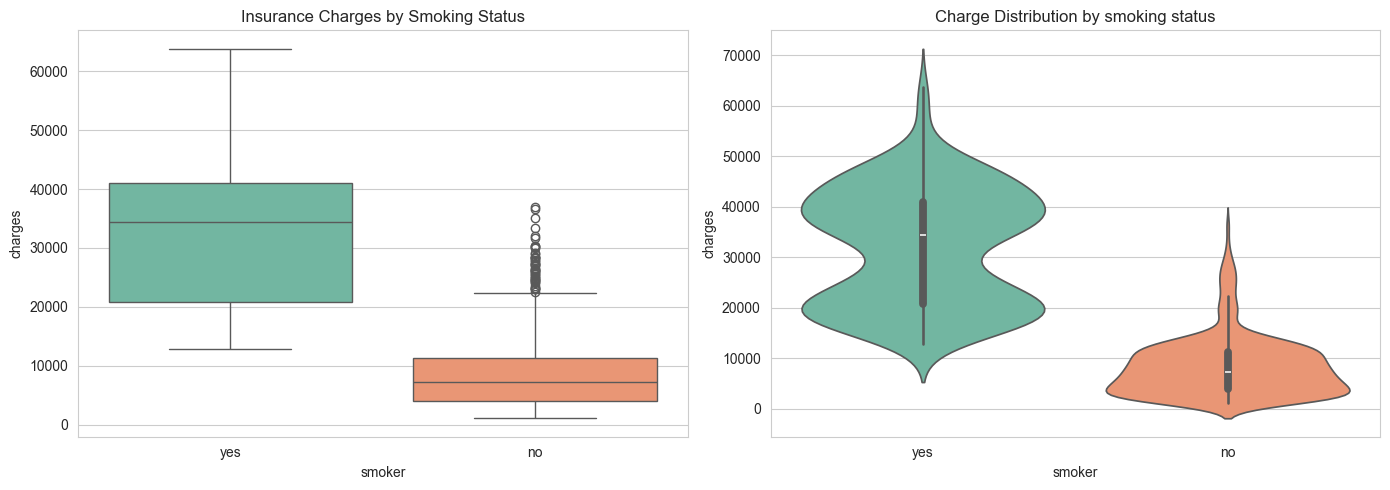

In [7]:
#charges by Smoker
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.boxplot(x='smoker',y='charges',data=df,ax=axes[0],palette='Set2')
axes[0].set_title('Insurance Charges by Smoking Status')

sns.violinplot(x='smoker',y='charges',data=df,ax=axes[1],palette='Set2')
axes[1].set_title('Charge Distribution by smoking status')

plt.tight_layout()
plt.savefig('../figures/charges_by_smoker.png',dpi=300,bbox_inches='tight')
plt.show()

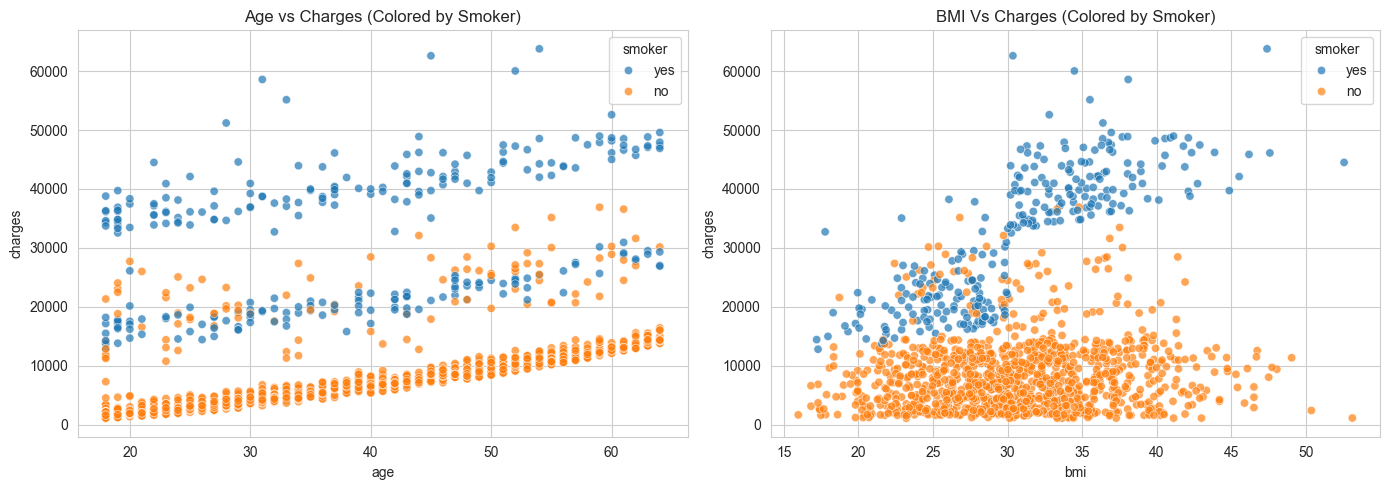

In [8]:
# Age & BMI Scatter Plots

fig,axes= plt.subplots(1,2,figsize=(14,5))
sns.scatterplot (x='age',y='charges',hue='smoker',data=df,alpha=0.7, ax=axes[0])
axes[0].set_title('Age vs Charges (Colored by Smoker)')

sns.scatterplot(x='bmi',y='charges',hue='smoker',data=df,alpha=0.7,ax=axes[1])
axes[1].set_title('BMI Vs Charges (Colored by Smoker)')

plt.tight_layout()
plt.savefig('../figures/scatter_age_bmi_charges.png',dpi=300,bbox_inches='tight')
plt.show()

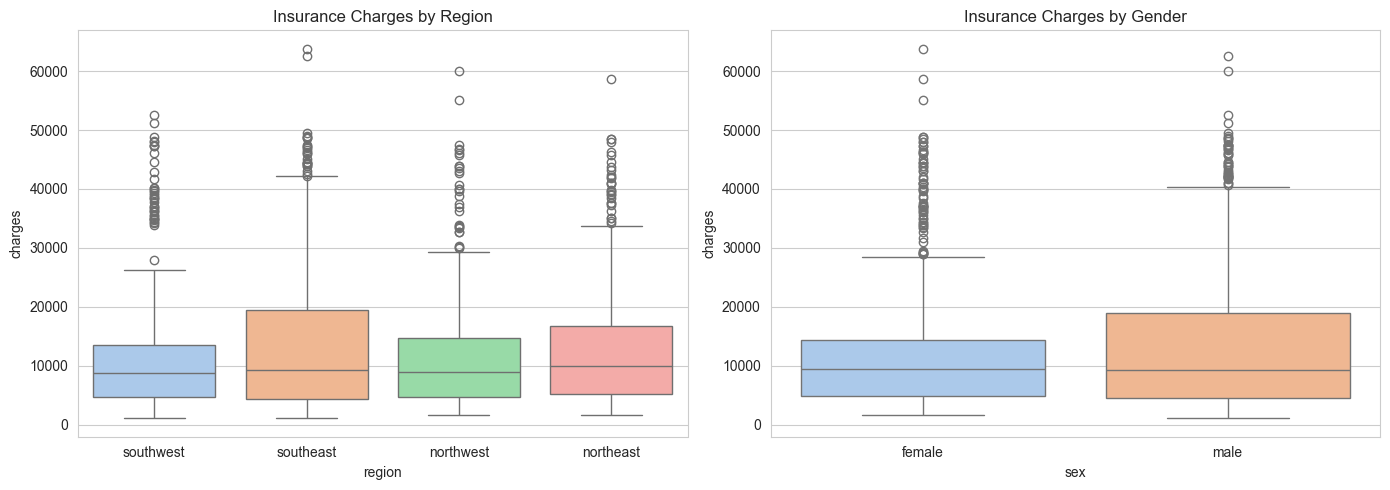

In [9]:
# Charges by Region and Gender

fig,axes= plt.subplots(1,2,figsize=(14,5))

sns.boxplot(x='region',y='charges',data=df,ax=axes[0],palette='pastel')
axes[0].set_title('Insurance Charges by Region')

sns.boxplot(x='sex',y='charges',data=df,ax=axes[1],palette='pastel')
axes[1].set_title('Insurance Charges by Gender')

plt.tight_layout()
plt.savefig('../figures/charges_by_region_gender.png',dpi=300,bbox_inches='tight')
plt.show()

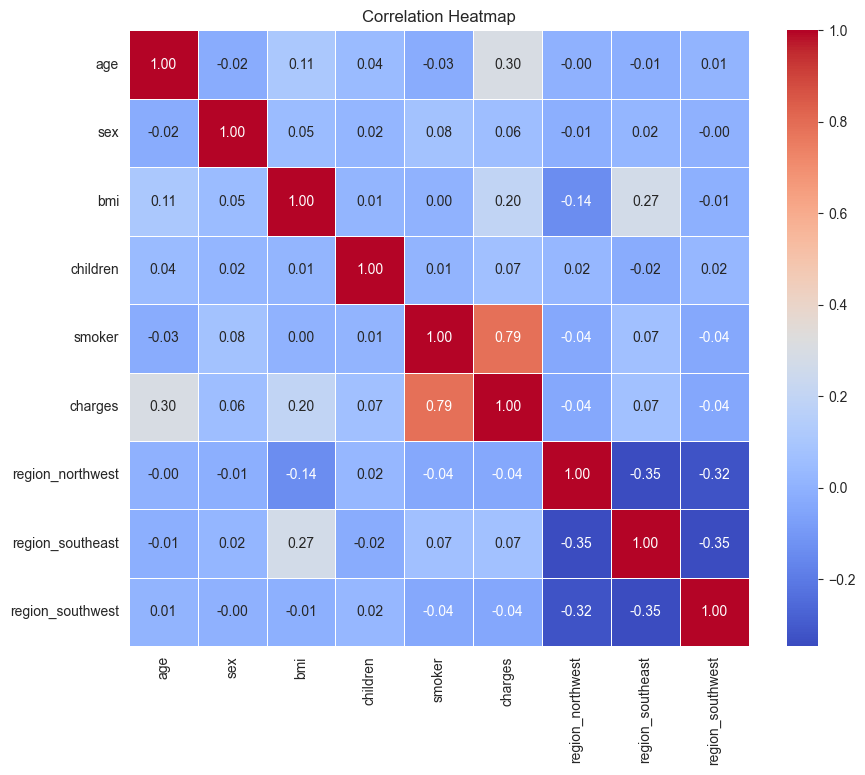

In [10]:
#Correlation heatmap

df_encoded= df.copy()
df_encoded['sex']=df_encoded['sex'].map({'male':1,'female':0})
df_encoded['smoker']=df_encoded['smoker'].map({'yes':1, 'no':0})
df_encoded =pd.get_dummies(df_encoded,columns=['region'],drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),annot= True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../figures/correlation_heatmap.png',dpi=300,bbox_inches='tight')


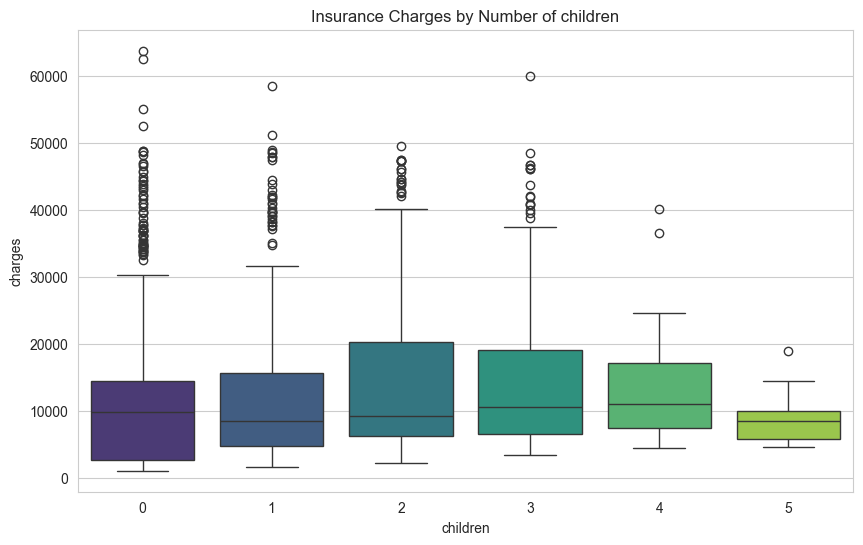

In [ ]:
# Charges by children

sns.boxplot(x='children',y='charges',data=df,palette='viridis')
plt.title('Insurance Charges by Number of children')
plt.savefig('../figures/charges_children.png',dpi=300,bbox_inches='tight')
plt.show()


Feature Engineering and Preprocessing


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=df_encoded.drop('charges',axis=1)
y=df_encoded['charges']

x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)

scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

print(f"Training set:{x_train.shape[0]} samples")
print(f"Test set:{x_test.shape[0]} samples")

Training set:1070 samples
Test set:268 samples


Machine Learning Models


In [13]:
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)
lr_pred = lr_model.predict(x_test_scaled)

print("=== Linear Regression ===")
print(f"MAE:  ${mean_absolute_error(y_test, lr_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, lr_pred)):,.2f}")
print(f"R²:   {r2_score(y_test, lr_pred):.4f}")

=== Linear Regression ===
MAE:  $4,181.19
RMSE: $5,796.28
R²:   0.7836


In [14]:
#RandomForestModel

from sklearn.ensemble import RandomForestRegressor

rf_model= RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
rf_pred=rf_model.predict(x_test)

print("..Random Forest....")
print(f"MAE:${mean_absolute_error(y_test,rf_pred):,.2f}")
print(f"RMSE:${np.sqrt(mean_squared_error(y_test,rf_pred)):,.2f}")
print(f"R2: ${r2_score(y_test,rf_pred):.4f}")






..Random Forest....
MAE:$2,550.67
RMSE:$4,577.74
R2: $0.8650


In [15]:
#Gradient Boosting:
from sklearn.ensemble import GradientBoostingRegressor

gb_model= GradientBoostingRegressor(n_estimators=200,learning_rate=0.1,max_depth=4,random_state=42)
gb_model.fit(x_train,y_train)
gb_pred= gb_model.predict(x_test)

print('...Gradient Boosting.....')
print(f"MAE: ${mean_absolute_error(y_test,gb_pred):,.2f}")
print(f"RMSE:${np.sqrt(mean_squared_error(y_test,gb_pred)):,.2f}")
print(f"R2: ${r2_score(y_test,gb_pred):.4f}")

...Gradient Boosting.....
MAE: $2,664.18
RMSE:$4,776.92
R2: $0.8530


Model Evaluation and Comparision


            Model         MAE        RMSE       R2
Linear Regression 4181.194474 5796.284659 0.783593
    Random Forest 2550.670151 4577.738988 0.865019
Gradient Boosting 2664.182036 4776.918626 0.853017


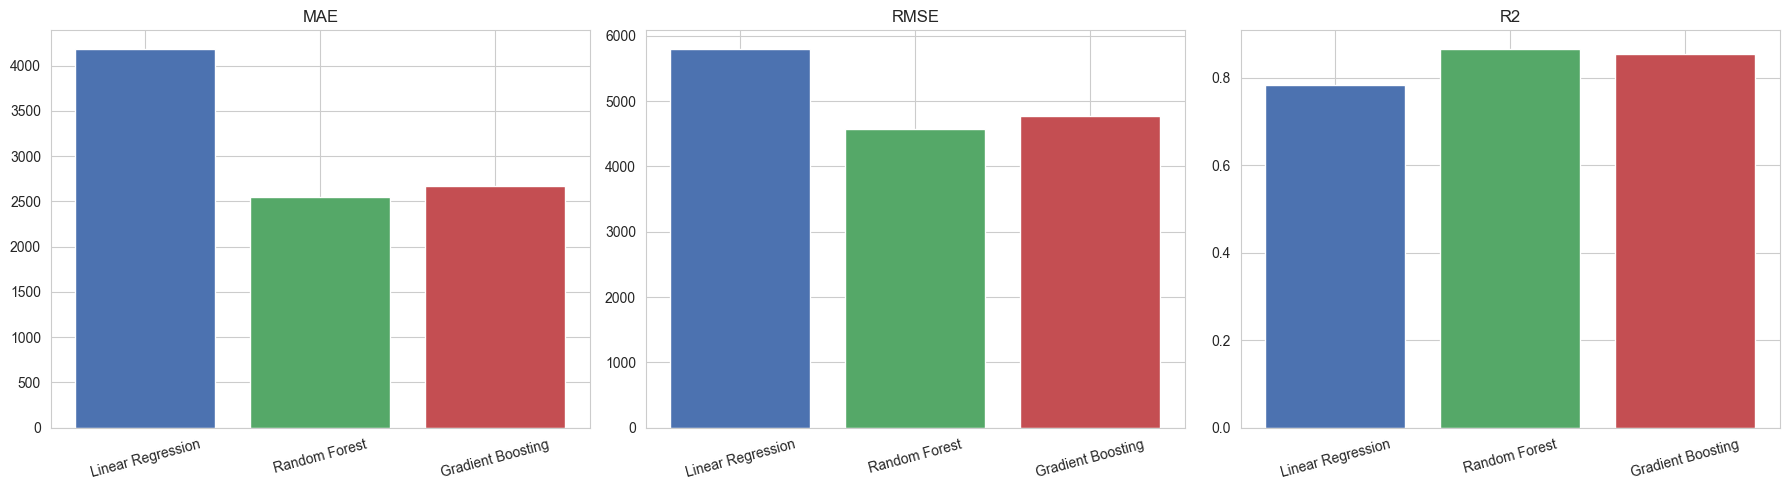

In [19]:
#Comparison Table & Bar Chart:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mean_absolute_error(y_test, lr_pred),
            mean_absolute_error(y_test, rf_pred),
            mean_absolute_error(y_test, gb_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_pred)),
             np.sqrt(mean_squared_error(y_test, rf_pred)),
             np.sqrt(mean_squared_error(y_test, gb_pred))],
    'R2': [r2_score(y_test, lr_pred),
           r2_score(y_test, rf_pred),
           r2_score(y_test, gb_pred)]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    axes[i].bar(results['Model'], results[metric], color=['#4C72B0', '#55A868', '#C44E52'])
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

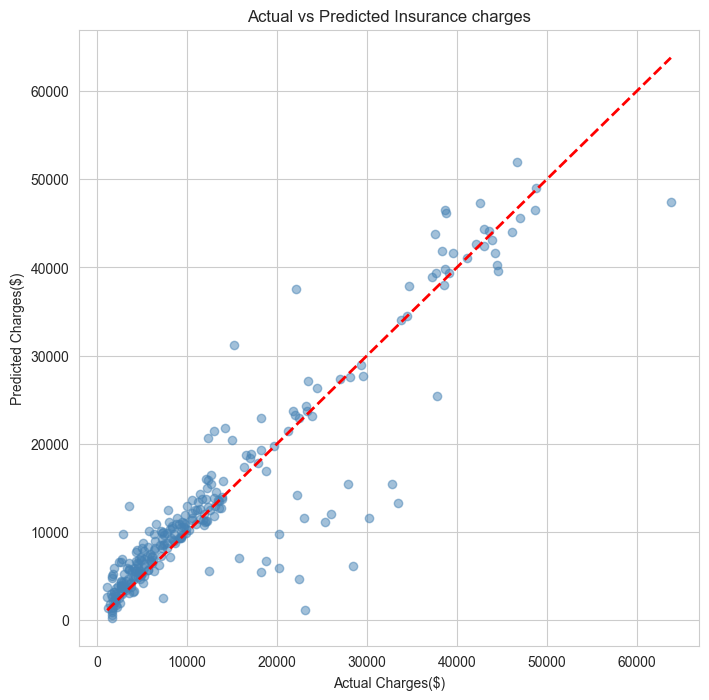

In [20]:
# Actual vs Predicted

best_pred= gb_pred

plt.figure(figsize=(8,8))
plt.scatter(y_test,best_pred,alpha=0.5,color='steelblue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
plt.xlabel('Actual Charges($)')
plt.ylabel('Predicted Charges($)')
plt.title('Actual vs Predicted Insurance charges')
plt.savefig('../figures/actual_vs_predicted.png',dpi=300,bbox_inches='tight')
plt.show()

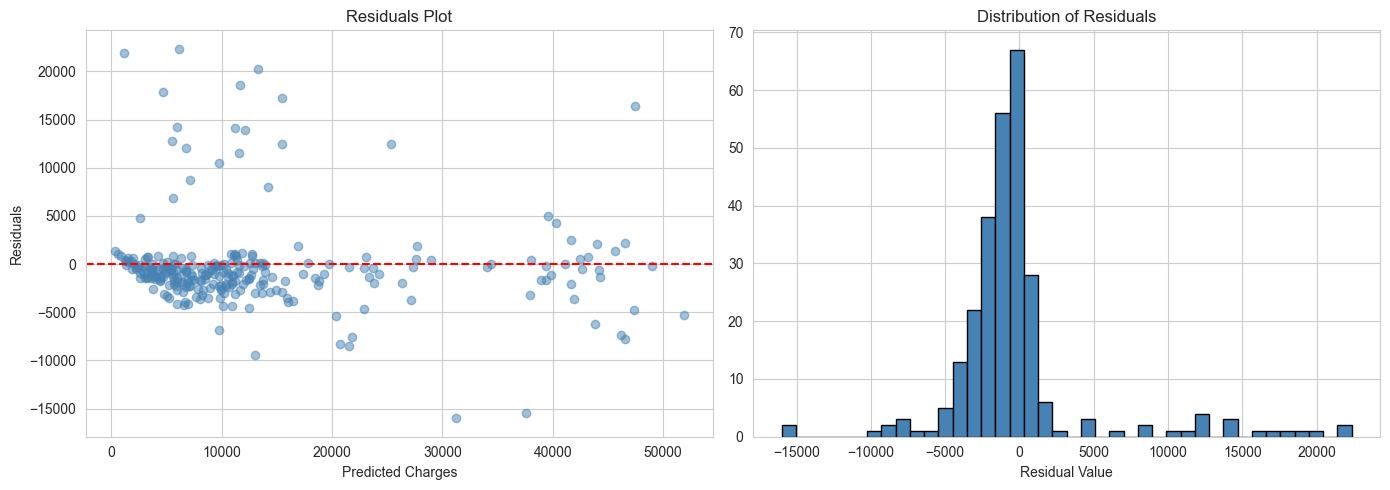

In [23]:
#Residual Analysis

residuals= y_test - best_pred

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(best_pred,residuals,alpha=0.5,color='steelblue')
axes[0].axhline(y=0,color='red',linestyle='--')
axes[0].set_xlabel('Predicted Charges')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals Plot')

axes[1].hist(residuals,bins=40,color='steelblue',edgecolor='black')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.savefig('../figures/residual_analysis.png',dpi=300,bbox_inches='tight')
plt.show()

HyperParameter Tuning

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(x_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

tuned_pred = grid_search.best_estimator_.predict(x_test)
print(f"Test R²: {r2_score(y_test, tuned_pred):.4f}")
print(f"Test MAE: ${mean_absolute_error(y_test, tuned_pred):,.2f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R²: 0.8486
Test R²: 0.8782
Test MAE: $2,520.75


SHAP Analysis

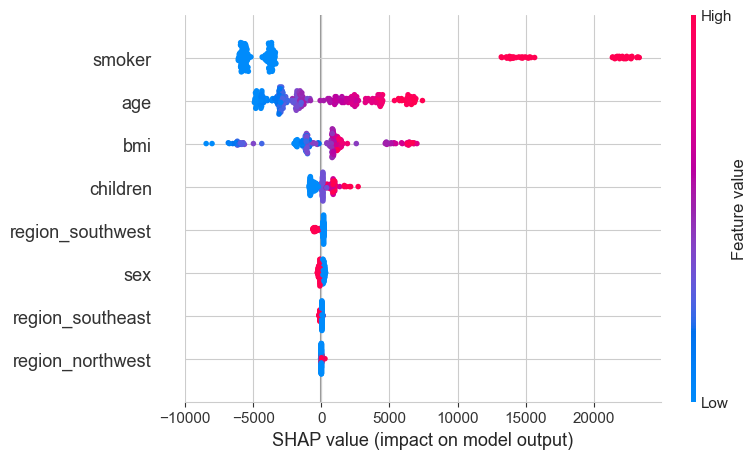

In [27]:
#SHAP Summary Plot:

import shap

best_model= grid_search.best_estimator_
explainer= shap.TreeExplainer(best_model)
shap_values= explainer.shap_values(x_test)

plt.figure()
shap.summary_plot(shap_values,x_test,show=False)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png',dpi=300,bbox_inches='tight')
plt.show()


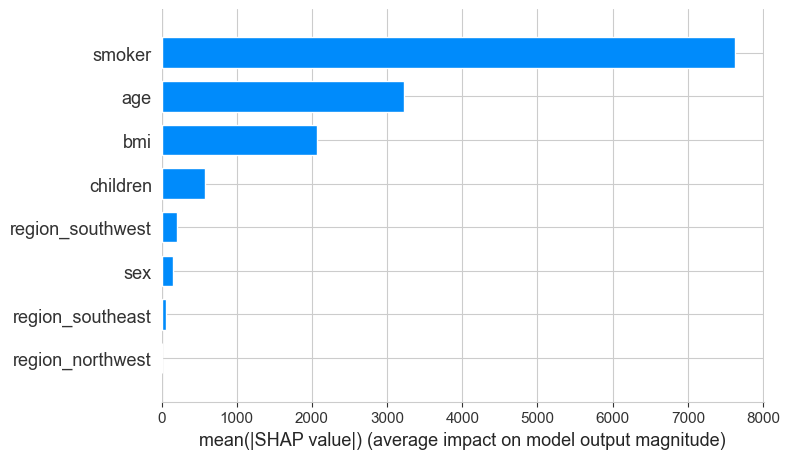

In [29]:
#SHAP Bar Plot:

plt.figure()
shap.summary_plot(shap_values, x_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

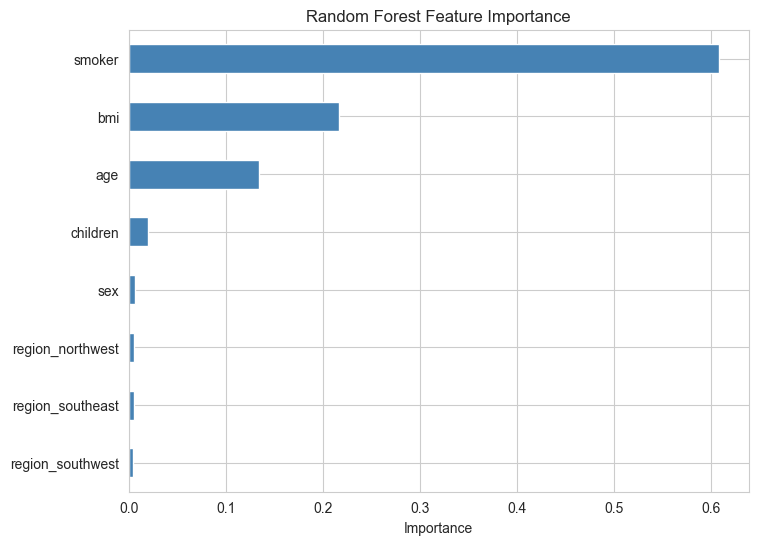

In [30]:
#Random Forest Feature Importance:

feat_importance = pd.Series(rf_model.feature_importances_, index=x.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.savefig('../figures/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Cross Validation

In [35]:
#5 fold CV:

from sklearn.model_selection import cross_val_score

models={
    'LinearRegression':LinearRegression(),
    'Random forest':RandomForestRegressor(n_estimators=100,random_state=42),
    'Gradient Boosting':GradientBoostingRegressor(n_estimators=200,learning_rate=0.1,max_depth=4,random_state=42)

}
for name ,model in models.items():
    scores=cross_val_score(model,x if name !='LinearRegression'else scaler.fit_transform(x),y,cv=5,scoring='r2')
    print(f"{name}:Mean R2={scores.mean():.4f}(+/-{scores.std():.4f})")


LinearRegression:Mean R2=0.7469(+/-0.0249)
Random forest:Mean R2=0.8361(+/-0.0324)
Gradient Boosting:Mean R2=0.8314(+/-0.0423)
